# SAXS-TT IsoNet — Training Data Inspector

Visualises exactly what the model consumes during training, to verify the
canonical-frame missing-wedge logic aligns correctly.

For each sample the `VolumeAugmentor` produces (on the training device):
- **target**  — a randomly SO(3)-rotated raw patch (supervision target).
- **carved**  — `target` with the *canonical* wedge of `k_wedge` removed (model input).
- **cond**    — scalar missing-arc embedding for `k_wedge`.
- **valid_missing** — where the Fourier loss is applied: inside the carved wedge
  AND where the (rotated) source `k_src` volume is genuinely measured.

What to check:
1. The dark wedge in `|FFT(carved)|` matches the **canonical keep-mask** (purple region).
2. `valid_missing` lies **inside** the carved wedge and **excludes** the rotated
   original missing wedge of the source.
3. `carved` and `target` differ only inside the carved wedge (Fourier support).

In [1]:
import sys, pathlib, tempfile
sys.path.insert(0, '/myhome/smartt')

import numpy as np
import torch
import matplotlib.pyplot as plt

from smartt.saxs_fbp import fibonacci_hemisphere
from smartt.saxs_isonet.wedge import goniometer_axis_for_half_space
from smartt.saxs_isonet.dataset import MissingWedgeSAXS, save_reconstruction_volumes
from smartt.saxs_isonet.augment import VolumeAugmentor
from torch.utils.data import DataLoader

# ── Parameters ────────────────────────────────────────────────────────────────
ISONET_DIR    = pathlib.Path('/myhome/data/smartt/shared/isonet_results/frogbone')
ALPHA_DEG     = 45.0
HALF_SPACE    = 'y'
PATCH         = 64
COND_DIM      = 64
MIN_WEDGE_DEG = 10.0
BATCH         = 6
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G_AXIS = goniometer_axis_for_half_space(HALF_SPACE)
print('device:', device)

# ── Load round_00 volumes + rsm_dirs, or synthesise a stand-in dataset ──────────
round0 = ISONET_DIR / 'round_00'
rsm_path = next((ISONET_DIR / n for n in ('rsm_dirs.npy', 'y_dirs.npy')
                 if (ISONET_DIR / n).exists()), None)

_tmp = None
if round0.exists() and rsm_path is not None and len(list(round0.glob('vol_*.npy'))) > 0:
    rsm_dirs = np.load(rsm_path)
    vol_dir = round0
    print(f'Loaded {len(rsm_dirs)} volumes from {vol_dir}')
else:
    print('[synthetic] frogbone round_00 not found — generating a stand-in dataset.')
    K = 12
    rng = np.random.RandomState(0)
    rsm_dirs = fibonacci_hemisphere(K, half_space=HALF_SPACE)
    # smooth-ish structured volumes so the FFT has anisotropic content
    vols = []
    for _ in range(K):
        v = rng.randn(72, 72, 72).astype(np.float32)
        vf = np.fft.fftn(v)
        kx = np.fft.fftfreq(72)
        decay = np.exp(-(kx[:, None, None]**2 + kx[None, :, None]**2 + kx[None, None, :]**2) / 0.01)
        vols.append(np.fft.ifftn(vf * decay).real.astype(np.float32))
    _tmp = tempfile.TemporaryDirectory()
    vol_dir = pathlib.Path(_tmp.name)
    save_reconstruction_volumes(torch.from_numpy(np.stack(vols)), vol_dir)

K = len(rsm_dirs)
print(f'K={K}  patch={PATCH}  alpha={ALPHA_DEG}  half_space={HALF_SPACE!r}')

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.


INFO:Setting numba log level to WARNING.


device: cuda
Loaded 30 volumes from /myhome/data/smartt/shared/isonet_results/frogbone/round_00
K=30  patch=64  alpha=45.0  half_space='y'


In [2]:
# Build dataset + augmentor, pull one batch, run the augmentation on `device`.
ds = MissingWedgeSAXS(vol_dir, rsm_dirs, ALPHA_DEG, goniometer_axis=G_AXIS,
                      patch_size=PATCH, n_samples=BATCH, min_wedge_deg=MIN_WEDGE_DEG)
loader = DataLoader(ds, batch_size=BATCH, drop_last=True)
aug = VolumeAugmentor(rsm_dirs, ALPHA_DEG, goniometer_axis=G_AXIS,
                      patch_size=PATCH, conditioning_dim=COND_DIM, device=device)

patch, k_src, k_wedge = next(iter(loader))
carved, target, cond, valid_missing = aug(patch, k_src, k_wedge)
carved = carved.cpu(); target = target.cpu(); valid_missing = valid_missing.cpu()

print('carved        ', tuple(carved.shape))
print('target        ', tuple(target.shape))
print('cond          ', tuple(cond.shape))
print('valid_missing ', tuple(valid_missing.shape), valid_missing.dtype)
print()
arcs = np.degrees([
    __import__('smartt.saxs_isonet.wedge', fromlist=['missing_arc_length'])
    .missing_arc_length(rsm_dirs[int(kw)], ALPHA_DEG, G_AXIS) for kw in k_wedge])
for s in range(BATCH):
    print(f'sample {s}: k_src={int(k_src[s]):2d}  k_wedge={int(k_wedge[s]):2d}  '
          f'missing_arc={arcs[s]:5.1f}°  valid_missing_voxels={int(valid_missing[s].sum())}')

INFO:Dataset: K=30 volumes, 21 eligible carve directions (min_wedge_deg=10.0°).


carved         (6, 1, 64, 64, 64)
target         (6, 1, 64, 64, 64)
cond           (6, 1, 64)
valid_missing  (6, 64, 64, 64) torch.bool

sample 0: k_src=18  k_wedge=17  missing_arc=117.9°  valid_missing_voxels=50490
sample 1: k_src= 5  k_wedge=18  missing_arc=104.3°  valid_missing_voxels=27029
sample 2: k_src= 6  k_wedge=12  missing_arc=155.7°  valid_missing_voxels=48186
sample 3: k_src= 2  k_wedge=16  missing_arc=128.6°  valid_missing_voxels=20704
sample 4: k_src=14  k_wedge=15  missing_arc=137.3°  valid_missing_voxels=38863
sample 5: k_src= 9  k_wedge=11  missing_arc=160.2°  valid_missing_voxels=39037


## Real-space slices

`target` (rotated patch) vs `carved` (wedge removed) vs their difference.  The
difference is band-limited — it lives only in the carved Fourier wedge, so in
real space it appears as a smooth, oriented ripple, not localised structure.

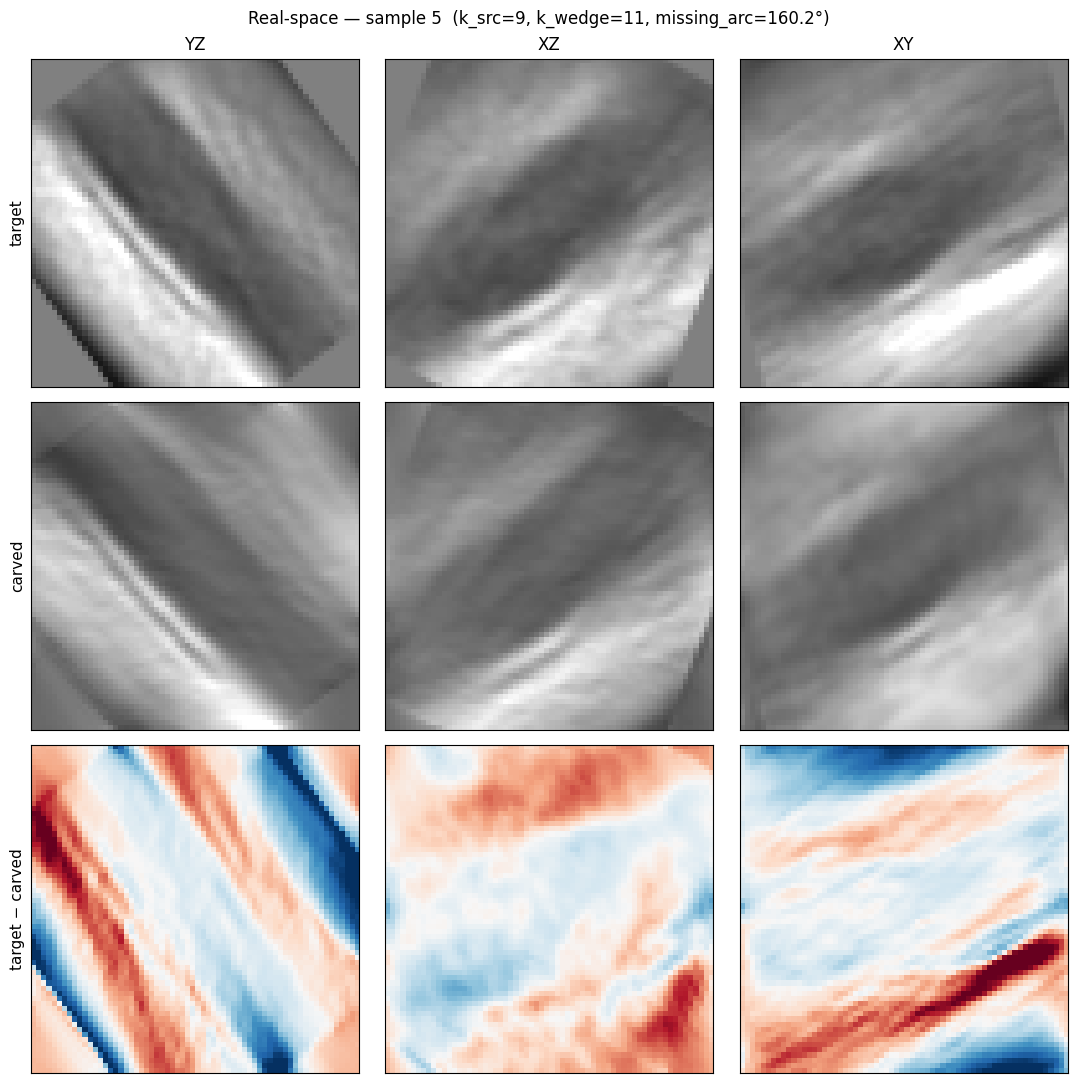

In [3]:
SAMPLE = 5   # change to inspect other samples in the batch

t = target[SAMPLE, 0].numpy()
c = carved[SAMPLE, 0].numpy()
d = t - c
mid = PATCH // 2
planes = [('YZ', lambda a: a[mid, :, :]), ('XZ', lambda a: a[:, mid, :]), ('XY', lambda a: a[:, :, mid])]

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
vlim = np.percentile(np.abs(t), 99)
for col, (name, sl) in enumerate(planes):
    axes[0, col].imshow(sl(t).T, origin='lower', cmap='gray', vmin=-vlim, vmax=vlim)
    axes[1, col].imshow(sl(c).T, origin='lower', cmap='gray', vmin=-vlim, vmax=vlim)
    dl = np.percentile(np.abs(d), 99)
    axes[2, col].imshow(sl(d).T, origin='lower', cmap='RdBu_r', vmin=-dl, vmax=dl)
    axes[0, col].set_title(name)
for r, lab in enumerate(['target', 'carved', 'target − carved']):
    axes[r, 0].set_ylabel(lab, fontsize=11)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Real-space — sample {SAMPLE}  (k_src={int(k_src[SAMPLE])}, '
             f'k_wedge={int(k_wedge[SAMPLE])}, missing_arc={arcs[SAMPLE]:.1f}°)', fontsize=12)
plt.tight_layout(); plt.show()

## Fourier-space alignment

All masks from the augmentor are in **fftshifted** layout (DC centred), the same
convention used by the training loss.  The canonical wedge always lies in the
xz-plane, so the **XZ** slice (y = centre) shows it best.

- `|FFT(carved)|` should be **dark** exactly where the canonical keep-mask is purple.
- `valid_missing` should sit inside that dark wedge **and** avoid the rotated
  original missing wedge of the source volume.

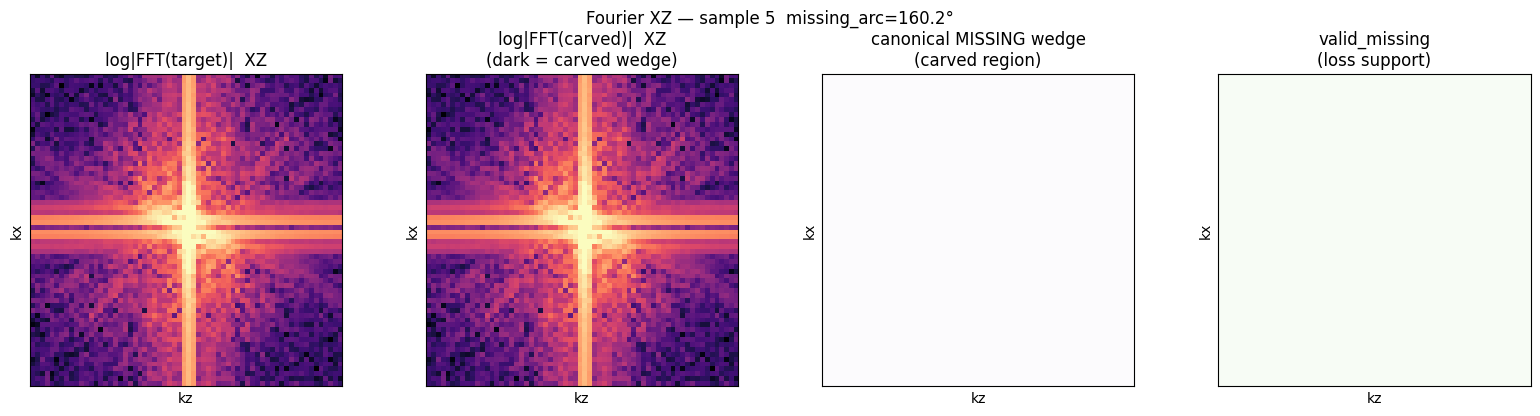

In [4]:
def xz(vol3d):
    return vol3d[:, PATCH // 2, :]

def log_fft_xz(real_vol):
    F = np.fft.fftshift(np.fft.fftn(real_vol))
    return np.log1p(np.abs(xz(F)))

keep_canon = aug.canonical_keep[k_wedge.to(aug.device)].cpu().numpy()  # (B,P,P,P) shifted, True=measured
vm = valid_missing.numpy()

ft_t = log_fft_xz(target[SAMPLE, 0].numpy())
ft_c = log_fft_xz(carved[SAMPLE, 0].numpy())
keep_xz = xz(keep_canon[SAMPLE])          # True = measured (kept)
vm_xz   = xz(vm[SAMPLE])                   # True = supervised

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
vmax = np.percentile(ft_t, 99)
axes[0].imshow(ft_t.T, origin='lower', cmap='magma', vmax=vmax); axes[0].set_title('log|FFT(target)|  XZ')
axes[1].imshow(ft_c.T, origin='lower', cmap='magma', vmax=vmax); axes[1].set_title('log|FFT(carved)|  XZ\n(dark = carved wedge)')
axes[2].imshow((~keep_xz).T, origin='lower', cmap='Purples'); axes[2].set_title('canonical MISSING wedge\n(carved region)')
axes[3].imshow(vm_xz.T, origin='lower', cmap='Greens');        axes[3].set_title('valid_missing\n(loss support)')
for ax in axes: ax.set_xlabel('kz'); ax.set_ylabel('kx'); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Fourier XZ — sample {SAMPLE}  missing_arc={arcs[SAMPLE]:.1f}°', fontsize=12)
plt.tight_layout(); plt.show()

## Numerical verification

Hard checks that the carving and loss mask are constructed correctly across the
whole batch (not just the displayed slice).

In [5]:
ok = True
for s in range(BATCH):
    keep = keep_canon[s].astype(bool)          # True = measured (shifted)
    miss = ~keep                                # carved wedge
    vms  = vm[s].astype(bool)

    # (1) valid_missing must be a strict subset of the carved (missing) region
    leak = int((vms & keep).sum())
    # (2) carved must have ~no power inside the canonical missing wedge.
    #     Use a RELATIVE residual (vs the carved volume's own peak magnitude) so
    #     the threshold is independent of the data scale — the absolute residual
    #     is just FFT round-trip floating-point error and grows with magnitude.
    Fc = np.fft.fftshift(np.fft.fftn(carved[s, 0].numpy()))
    peak = np.abs(Fc).max()
    rel_resid = (np.abs(Fc[miss]).max() / peak) if (miss.any() and peak > 0) else 0.0
    # (3) valid_missing should be non-empty for an eligible wedge
    nvm = int(vms.sum())

    flag = '' if (leak == 0 and rel_resid < 1e-5 and nvm > 0) else '  ←❌'
    if flag: ok = False
    print(f'sample {s}: leak_into_measured={leak:5d}  '
          f'rel.residual in wedge={rel_resid:.2e}  valid_missing={nvm:6d}{flag}')

print()
print('ALL CHECKS PASSED ✅' if ok else 'SOME CHECKS FAILED ❌')

sample 0: leak_into_measured=    0  rel.residual in wedge=1.34e-08  valid_missing= 50490
sample 1: leak_into_measured=    0  rel.residual in wedge=1.18e-08  valid_missing= 27029
sample 2: leak_into_measured=    0  rel.residual in wedge=1.28e-08  valid_missing= 48186
sample 3: leak_into_measured=    0  rel.residual in wedge=1.30e-08  valid_missing= 20704
sample 4: leak_into_measured=    0  rel.residual in wedge=1.06e-08  valid_missing= 38863
sample 5: leak_into_measured=    0  rel.residual in wedge=1.43e-08  valid_missing= 39037

ALL CHECKS PASSED ✅
